# Lita Research Log Analysis

`research_logs/` 以下の CSV を読み込んで Lita の内部動作を分析する。

| ファイル | 内容 |
|---|---|
| `conversations/` | user_message / ai_response / proactive_intervention イベント |
| `thoughts/` | 思考生成・ブレーキ評価・発話判定ログ |
| `internal_state/` | loneliness / curiosity / social_energy の時系列 |

In [12]:
import pandas as pd
import glob
import json
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.patches as mpatches
import matplotlib_fontja  # 日本語フォント
from pathlib import Path

LOG_DIR = Path("research_logs")

# ── conversations ──────────────────────────────────────────────────
conv_files = sorted(glob.glob(str(LOG_DIR / "conversations" / "*.csv")))
if conv_files:
    conv = pd.concat([pd.read_csv(f) for f in conv_files], ignore_index=True)
    conv["timestamp"] = pd.to_datetime(conv["timestamp"])
    conv["metadata"] = conv["metadata"].apply(
        lambda x: json.loads(x) if pd.notna(x) and x else {}
    )
    print(f"conversations : {len(conv):>4} rows  ({len(conv_files)} files)")
else:
    conv = pd.DataFrame()
    print("conversations : no data")

# ── thoughts ───────────────────────────────────────────────────────
thought_files = sorted(glob.glob(str(LOG_DIR / "thoughts" / "*.csv")))
if thought_files:
    thoughts = pd.concat([pd.read_csv(f) for f in thought_files], ignore_index=True)
    thoughts["timestamp"] = pd.to_datetime(thoughts["timestamp"])
    thoughts["evaluation_details"] = thoughts["evaluation_details"].apply(
        lambda x: json.loads(x) if pd.notna(x) and x else {}
    )
    print(f"thoughts      : {len(thoughts):>4} rows  ({len(thought_files)} files)")
else:
    thoughts = pd.DataFrame()
    print("thoughts      : no data")

# ── internal_state ─────────────────────────────────────────────────
state_files = sorted(glob.glob(str(LOG_DIR / "internal_state" / "*.csv")))
if state_files:
    states = pd.concat([pd.read_csv(f) for f in state_files], ignore_index=True)
    states["timestamp"] = pd.to_datetime(states["timestamp"])
    print(f"internal_state: {len(states):>4} rows  ({len(state_files)} files)")
else:
    states = pd.DataFrame()
    print("internal_state: no data yet")

conversations :   18 rows  (4 files)
thoughts      :    2 rows  (1 files)
internal_state: no data yet


## 1. 基本統計

In [13]:
if not conv.empty:
    counts = conv["event_type"].value_counts()
    user_msgs   = counts.get("user_message", 0)
    ai_reactive = counts.get("ai_response", 0)
    ai_proactive = counts.get("proactive_intervention", 0)
    total_ai = ai_reactive + ai_proactive

    print(f"総イベント数          : {len(conv)}")
    print(f"ユーザーメッセージ    : {user_msgs}")
    print(f"AI 反応的応答         : {ai_reactive}")
    print(f"AI 自発的介入         : {ai_proactive}")
    if total_ai > 0:
        print(f"Proactive 率          : {ai_proactive / total_ai * 100:.1f}%")
    print()

    print("── セッション別 ──")
    for sid, g in conv.groupby("session_id"):
        c = g["event_type"].value_counts()
        dur = (g["timestamp"].max() - g["timestamp"].min()).total_seconds() / 60
        print(f"  {sid}: {len(g)} events, {dur:.0f} min  "
              f"user={c.get('user_message',0)}  "
              f"reactive={c.get('ai_response',0)}  "
              f"proactive={c.get('proactive_intervention',0)}")
else:
    print("No conversation data")

総イベント数          : 18
ユーザーメッセージ    : 8
AI 反応的応答         : 7
AI 自発的介入         : 3
Proactive 率          : 30.0%

── セッション別 ──
  35c60aca: 2 events, 0 min  user=1  reactive=1  proactive=0
  3e57ea44: 2 events, 0 min  user=1  reactive=1  proactive=0
  6245221b: 7 events, 30 min  user=3  reactive=3  proactive=1
  ad61d330: 7 events, 33 min  user=3  reactive=2  proactive=2


## 2. 内部状態の時系列

loneliness / curiosity / social_energy の推移を、会話イベントの発生タイミングと重ねて表示する。

In [14]:
if states.empty:
    print("内部状態ログがまだありません（会話を続けるとデータが溜まります）")
else:
    users = states["user_id"].unique()

    for user_id in users:
        df = states[states["user_id"] == user_id].sort_values("timestamp")

        fig, (ax_state, ax_events) = plt.subplots(
            2, 1, figsize=(14, 7), sharex=True,
            gridspec_kw={"height_ratios": [3, 1]}
        )
        fig.suptitle(f"Lita Internal State  –  user: {user_id}", fontsize=13)

        # ── 状態の折れ線 ──────────────────────────────────────
        ax_state.plot(df["timestamp"], df["loneliness"],
                      label="孤独感", color="#e06c75", linewidth=1.5)
        ax_state.plot(df["timestamp"], df["curiosity"],
                      label="好奇心", color="#61afef", linewidth=1.5)
        ax_state.plot(df["timestamp"], df["social_energy"],
                      label="社交エネルギー", color="#98c379", linewidth=1.5)

        # conversation_update をマーカーで強調
        cu = df[df["trigger"] == "conversation_update"]
        for col, color in [("loneliness", "#e06c75"), ("curiosity", "#61afef"), ("social_energy", "#98c379")]:
            ax_state.scatter(cu["timestamp"], cu[col], color=color, s=40, zorder=5)

        ax_state.set_ylim(0, 10)
        ax_state.set_ylabel("値 (0–10)")
        ax_state.legend(loc="upper left", fontsize=9)
        ax_state.grid(axis="y", alpha=0.3)

        # ── イベントタイムライン ──────────────────────────────
        if not conv.empty:
            user_conv = conv[conv["user_id"] == user_id].sort_values("timestamp")
            event_config = [
                ("user_message",           "#61afef", "▲", 1.0, "User msg"),
                ("ai_response",            "#98c379", "●", 0.6, "Reactive"),
                ("proactive_intervention", "#e5c07b", "★", 1.0, "Proactive"),
            ]
            for et, color, marker, alpha, label in event_config:
                ev = user_conv[user_conv["event_type"] == et]
                if not ev.empty:
                    ax_events.scatter(
                        ev["timestamp"], [0.5] * len(ev),
                        color=color, marker=marker, s=60, alpha=alpha,
                        label=label, zorder=5
                    )
        # reaction イベント（ai_response のうち metadata type=reaction）
        if not conv.empty:
            reactions = conv[
                (conv["user_id"] == user_id) &
                (conv["event_type"] == "ai_response") &
                conv["metadata"].apply(lambda m: m.get("type") == "reaction")
            ]
            if not reactions.empty:
                ax_events.scatter(
                    reactions["timestamp"], [0.5] * len(reactions),
                    color="#c678dd", marker="♦", s=60, alpha=0.9,
                    label="Reaction", zorder=6
                )

        ax_events.set_ylim(0, 1)
        ax_events.set_yticks([])
        ax_events.set_ylabel("Events")
        ax_events.legend(loc="upper left", fontsize=8, ncol=4)
        ax_events.grid(axis="x", alpha=0.3)

        ax_events.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        fig.autofmt_xdate(rotation=30)
        plt.tight_layout()
        plt.show()

内部状態ログがまだありません（会話を続けるとデータが溜まります）


## 3. 思考プロセスの分析

思考の生成・評価・発話判定の統計と分布。

In [15]:
if thoughts.empty:
    print("思考ログがまだありません")
else:
    total    = len(thoughts)
    expressed = thoughts["was_expressed"].sum()
    scores    = thoughts["motivation_score"]

    print(f"生成された思考数  : {total}")
    print(f"発話された思考    : {expressed}  ({expressed/total*100:.0f}%)")
    print(f"沈黙した思考      : {total - expressed}  ({(total-expressed)/total*100:.0f}%)")
    print()
    print("Motivation Score:")
    print(f"  平均   : {scores.mean():.2f}")
    print(f"  中央値 : {scores.median():.2f}")
    print(f"  最小   : {scores.min():.2f}")
    print(f"  最大   : {scores.max():.2f}")
    print()

    # トリガー別
    print("── トリガー別 ──")
    for trigger, g in thoughts.groupby("trigger_reason"):
        e = g["was_expressed"].sum()
        print(f"  {trigger[:50]:<50} | "
              f"{len(g):>3} thoughts  {e:>3} expressed  "
              f"avg={g['motivation_score'].mean():.2f}")

生成された思考数  : 2
発話された思考    : 2  (100%)
沈黙した思考      : 0  (0%)

Motivation Score:
  平均   : 4.00
  中央値 : 4.00
  最小   : 4.00
  最大   : 4.00

── トリガー別 ──
  periodic (42s since last message)                  |   1 thoughts    1 expressed  avg=4.00
  periodic (46s since last message)                  |   1 thoughts    1 expressed  avg=4.00


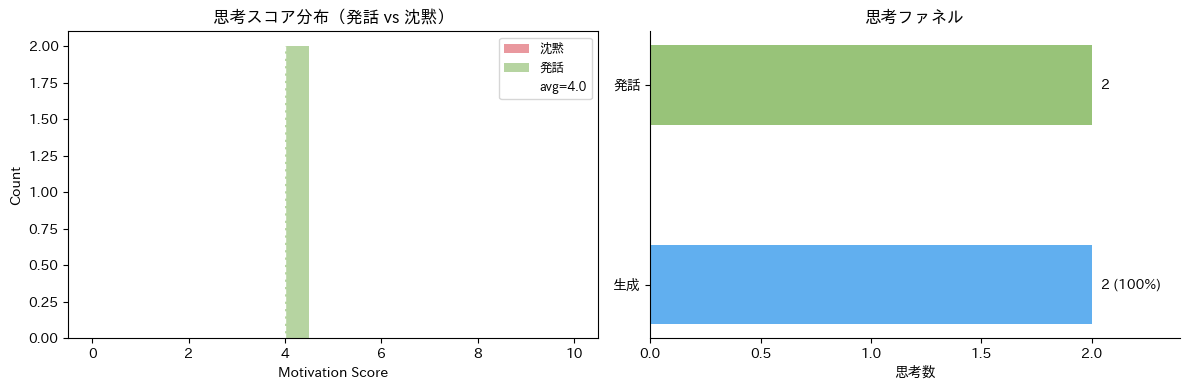

In [16]:
if not thoughts.empty:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    # ── 左: Motivation Score ヒストグラム ──────────────────────
    ax = axes[0]
    expressed_scores  = thoughts[thoughts["was_expressed"] == True]["motivation_score"]
    suppressed_scores = thoughts[thoughts["was_expressed"] == False]["motivation_score"]
    bins = [i * 0.5 for i in range(21)]
    ax.hist(suppressed_scores, bins=bins, color="#e06c75", alpha=0.7, label="沈黙")
    ax.hist(expressed_scores,  bins=bins, color="#98c379", alpha=0.7, label="発話")
    ax.axvline(x=thoughts["motivation_score"].mean(), color="white", linestyle="--",
               linewidth=1, label=f"avg={thoughts['motivation_score'].mean():.1f}")
    ax.set_xlabel("Motivation Score")
    ax.set_ylabel("Count")
    ax.set_title("思考スコア分布（発話 vs 沈黙）")
    ax.legend(fontsize=9)

    # ── 右: 発話/沈黙ファネル ──────────────────────────────────
    ax2 = axes[1]
    total     = len(thoughts)
    expressed = int(thoughts["was_expressed"].sum())
    ax2.barh(["生成", "発話"], [total, expressed],
             color=["#61afef", "#98c379"], height=0.4)
    ax2.set_xlim(0, total * 1.2)
    for spine in ["top", "right"]:
        ax2.spines[spine].set_visible(False)
    ax2.set_title("思考ファネル")
    ax2.set_xlabel("思考数")
    # ラベル
    ax2.text(total + total * 0.02, 1, f"{total}", va="center", fontsize=10)
    ax2.text(expressed + total * 0.02, 0,
             f"{expressed} ({expressed/total*100:.0f}%)", va="center", fontsize=10)

    plt.tight_layout()
    plt.show()

## 4. 思考タイムライン

いつどんなスコアの思考が発生し、発話されたかを時系列で表示。

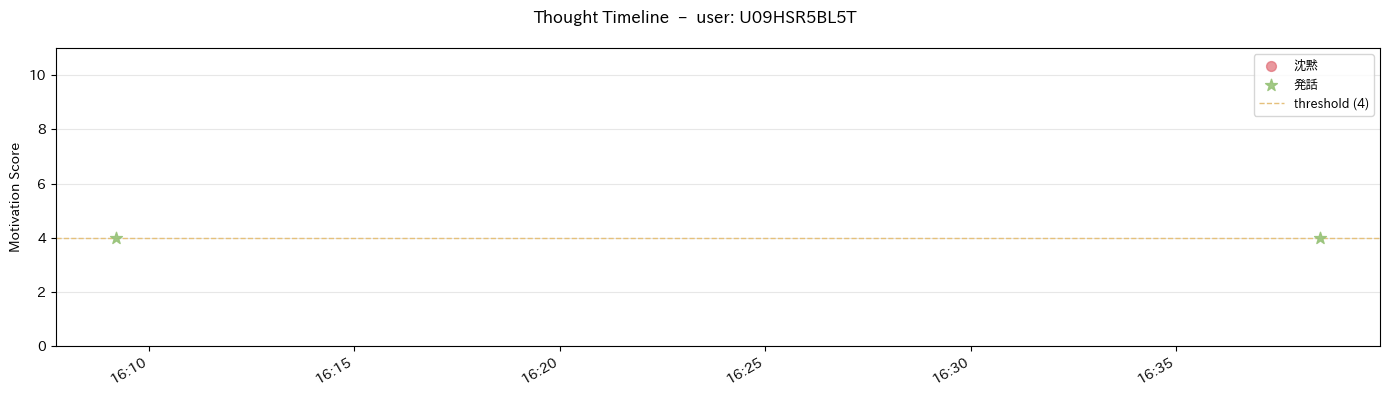

In [17]:
if not thoughts.empty:
    users = thoughts["user_id"].unique()
    for user_id in users:
        df = thoughts[thoughts["user_id"] == user_id].sort_values("timestamp")

        fig, ax = plt.subplots(figsize=(14, 4))
        fig.suptitle(f"Thought Timeline  –  user: {user_id}", fontsize=12)

        expressed  = df[df["was_expressed"] == True]
        suppressed = df[df["was_expressed"] == False]

        ax.scatter(suppressed["timestamp"], suppressed["motivation_score"],
                   color="#e06c75", s=50, alpha=0.7, label="沈黙", zorder=4)
        ax.scatter(expressed["timestamp"], expressed["motivation_score"],
                   color="#98c379", s=80, marker="*", alpha=0.9, label="発話", zorder=5)

        # スコア閾値ライン
        try:
            import config
            threshold = config.MOTIVATION_THRESHOLD
        except Exception:
            threshold = 4
        ax.axhline(y=threshold, color="#e5c07b", linestyle="--",
                   linewidth=1, label=f"threshold ({threshold})")

        ax.set_ylim(0, 11)
        ax.set_ylabel("Motivation Score")
        ax.legend(fontsize=9)
        ax.grid(axis="y", alpha=0.3)
        ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
        fig.autofmt_xdate(rotation=30)
        plt.tight_layout()
        plt.show()

## 5. 応答時間・Proactive 受容率

In [18]:
if not conv.empty:
    s = conv.sort_values("timestamp").reset_index(drop=True)

    # ユーザー発言 → AI 応答
    resp_times = [
        (s.iloc[i+1]["timestamp"] - s.iloc[i]["timestamp"]).total_seconds()
        for i in range(len(s)-1)
        if s.iloc[i]["event_type"] == "user_message"
           and s.iloc[i+1]["event_type"] == "ai_response"
    ]
    # Proactive 後のユーザー返答時間
    user_reply_times = [
        (s.iloc[i+1]["timestamp"] - s.iloc[i]["timestamp"]).total_seconds()
        for i in range(len(s)-1)
        if s.iloc[i]["event_type"] == "proactive_intervention"
           and s.iloc[i+1]["event_type"] == "user_message"
    ]

    if resp_times:
        med = sorted(resp_times)[len(resp_times)//2]
        print(f"AI 応答時間 (user→AI):           平均 {sum(resp_times)/len(resp_times):.1f}s  中央値 {med:.1f}s")
    if user_reply_times:
        med = sorted(user_reply_times)[len(user_reply_times)//2]
        print(f"Proactive 後のユーザー返答時間:  平均 {sum(user_reply_times)/len(user_reply_times):.1f}s  中央値 {med:.1f}s")

    # Proactive 受容率
    pi = s[s["event_type"] == "proactive_intervention"].index
    accepted = sum(
        1 for idx in pi
        if idx+1 < len(s) and s.iloc[idx+1]["event_type"] == "user_message"
    )
    total_pi = len(pi)
    if total_pi:
        print(f"\nProactive 受容率: {accepted}/{total_pi} ({accepted/total_pi*100:.0f}%)")
    else:
        print("\nProactive 発言なし")
else:
    print("No data")

AI 応答時間 (user→AI):           平均 8.2s  中央値 13.0s
Proactive 後のユーザー返答時間:  平均 100.1s  中央値 100.1s

Proactive 受容率: 1/3 (33%)


## 6. 会話プレビュー

In [19]:
if not conv.empty:
    N = 30
    recent = conv.sort_values("timestamp").tail(N)

    COLOR = {
        "user_message":           "\033[94m",   # blue
        "ai_response":            "\033[92m",   # green
        "proactive_intervention": "\033[93m",   # yellow
    }
    LABEL = {
        "user_message":           "User    ",
        "ai_response":            "Lita    ",
        "proactive_intervention": "Lita(→) ",
    }
    RESET = "\033[0m"

    for _, row in recent.iterrows():
        ts      = row["timestamp"].strftime("%m/%d %H:%M:%S")
        et      = row["event_type"]
        content = str(row["content"])[:100]
        color   = COLOR.get(et, "")
        label   = LABEL.get(et, et)
        print(f"[{ts}] {color}{label}{RESET}: {content}")
else:
    print("No data")

[02/27 17:57:01] User    : こんばんは
[02/27 17:57:14] Lita    : [reaction: heart]
[03/05 16:06:32] User    : こんにちは
[03/05 16:09:12] Lita(→) : こんにちは！何かお手伝いできることがありますか？
[03/05 16:10:52] User    : 特にないけどお話しよ～
今日県外まで行ったから疲れた～
[03/05 16:11:09] Lita    : [reaction: tired_face]
[03/05 16:34:56] User    : ところでLitaは今日なにしてた？
[03/05 16:38:29] Lita(→) : 今日も友達と図書館で漫画読んでたよ～疲れたなら、ぜひおやつでも食べてリフレッシュ！私は今、お茶を淹れてる最中なんだよ
[03/05 16:39:58] Lita    : 私はただユーザーさんを待っていたよ～。県外行くのは大変だったね！帰ってきてよかった。
[03/05 17:04:36] User    : こんにちは、元気？
[03/05 17:04:50] Lita    : [reaction: smile]
[03/05 17:08:22] User    : こんにちは、元気？
[03/05 17:08:23] Lita    : 元気だよ！今日なんか楽しいことあった？
[03/05 17:08:56] User    : 今日はね～県外まで仕事で往訪に行って大変だった～
[03/05 17:08:59] Lita    : 県外まで往復って、結構距離あったんだね…  
移動だけで疲れちゃうよね。ご飯、ちゃんと食べた？
[03/05 17:09:15] User    : 食べたよ～
[03/05 17:09:16] Lita    : [reaction: thumbsup]
[03/05 17:38:15] Lita(→) : 県外往復、移動大変だったのにご飯ちゃんと食べたの、すごいよ！帰り道、何か気になったことあった？
